© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# **Array Fundamentals**

**Deep Network Development W04/A**

**Topic:** slicing a grid along both axes, locating a maximum and converting its position, combining arrays whose shapes differ, and the matrix product.

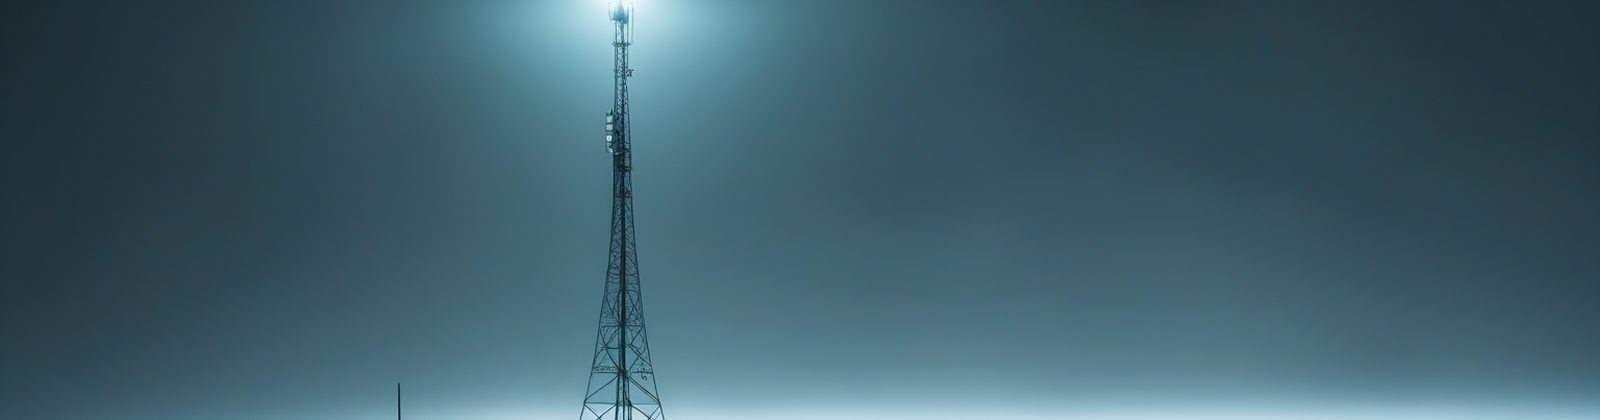

## **What this is**

Four parts on a 240 by 360 grid of integers. Parts a and b index and slice the grid along both axes. Parts c and d combine it with arrays of a different shape.

| Part | Asks for | Points |
|---|---|---:|
| a | The sum inside 30 rectangular windows | 25 |
| b | Where the largest value sits, 30 times | 25 |
| c | One value from the grid after a per-column offset is subtracted, 30 times | 25 |
| d | 30 entries of a matrix product | 25 |

Each part wants a CSV with columns `id,target`, one integer per row, scored exact-match: `points * (correct rows / total rows)`.

Part c subtracts a 360 element vector from a 240 by 360 grid. Part d multiplies a 48 by 36 matrix by a 36 by 52 one. Both depend on getting the shapes the right way round.

## **What exactly is being asked**

`grid.npy` is a 2D array of integer measurements, 240 rows by 360 columns. `queries.json` holds what each part asks about. Indices are **0-based**.

**Part a, from `windows`.** Each window is `[r0, r1, c0, c1]`. Report the **sum** of the values inside it. The bounds are **half-open**, exactly as Python slicing means them: row `r0` is inside, row `r1` is not. Answers are integers.

**Part b, two row groups.**

Rows `id = 0..14`, from `rows`: for each queried row of the grid, report the **column index** of the largest value in that row.

Rows `id = 15..29`, from `peak_bands`: for each queried band `[c0, c1]`, find the largest value anywhere in that band and report its **flat index into the whole grid**, meaning `row * 360 + column`. Every queried row and band has a single unmistakable maximum, so there are no ties to worry about.

**Part c, from `bcast`.** `offsets.npy` has shape `(360,)`: one offset per **column** of the grid. Subtract `offsets` from the whole of `grid`, so that each column's offset applies to that column on every row. Then each query `[r, c]` reads one value out of the result.

The shapes are `(240, 360)` and `(360,)`. They are compatible as they stand; you do not need to reshape anything, and if you find yourself writing a loop over rows, stop and reread this paragraph.

**Part d, from `matmul`.** `left.npy` is `(48, 36)` and `right.npy` is `(36, 52)`. Compute their matrix product and report the entry at each query `[i, j]`.

**Parts c and d report the value times 100, rounded to the nearest whole number**, so you are always submitting integers. A value of `4.7213` is reported as `472`. Parts a and b are already integers and are reported as they are.

## **Useful Links**

- [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)
- [Indexing and slicing](https://numpy.org/doc/stable/user/basics.indexing.html)
- [Routines reference](https://numpy.org/doc/stable/reference/routines.html)

## **Setup and data**

In [21]:
# ══════════════════════════════════════════════════════════
# Setup. DO NOT MODIFY.
# ══════════════════════════════════════════════════════════
import csv
import json
from pathlib import Path

import numpy as np

def write_submission(filename, rows):
    """Write [(id, target), ...] as a DOCK-ready CSV.

    Every part of every exercise this semester ends with a call like this one.
    """
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["id", "target"])
        for row_id, target in rows:
            writer.writerow([int(row_id), int(target)])
    print(f"wrote {filename}: {len(rows)} rows")

# Download the .npy files and queries.json from the exercise page on DOCK and put
# them next to this notebook (in Colab: drag them into the file browser on the left).
def _find(name):
    here = Path(name)
    return here if here.exists() else Path("data") / name

grid = np.load(_find("grid.npy"))
offsets = np.load(_find("offsets.npy"))
left = np.load(_find("left.npy"))
right = np.load(_find("right.npy"))
queries = json.loads(_find("queries.json").read_text(encoding="utf-8"))

windows = queries["windows"]
rows = queries["rows"]
peak_bands = queries["peak_bands"]
bcast = queries["bcast"]
matmul = queries["matmul"]

print(f"grid: {grid.shape} {grid.dtype}, values {grid.min()} to {grid.max()}")
print(f"offsets: {offsets.shape}   left: {left.shape}   right: {right.shape}")
print(f"{len(windows)} windows, {len(rows)} rows, {len(peak_bands)} bands, "
      f"{len(bcast)} positions, {len(matmul)} product entries")

grid: (240, 360) int64, values 8 to 271
offsets: (360,)   left: (48, 36)   right: (36, 52)
30 windows, 15 rows, 15 bands, 30 positions, 30 product entries


---
## **Part a: Window sums (25 points)**

Submission: `part1_submission.csv`, one row per window, uploaded to part a.

In [22]:
part1 = [[i, 0] for i in range(len(windows))]

# ── Your code starts here ──
for i in range(len(windows)):
    r0, r1, c0, c1 = windows[i]
    part1[i][1] = np.sum(grid[r0:r1, c0:c1])

write_submission("part1_submission.csv", part1)
part1[:5]


wrote part1_submission.csv: 30 rows


[[0, np.int64(257700)],
 [1, np.int64(162909)],
 [2, np.int64(585835)],
 [3, np.int64(235323)],
 [4, np.int64(405992)]]

In [17]:
part1 = [[i, 0] for i in range(len(windows))]
print(windows[0])

x = np.arange(215,228)
y = np.arange(113,223)

print(grid[x][y])

write_submission("part1_submission.csv", part1)
part1[:5]

[215, 228, 113, 223]


IndexError: index 113 is out of bounds for axis 0 with size 13

---
## **Part b: Finding the maximum (25 points)**

Two row groups, graded together, so getting one right is worth real points.

Watch the second group. A band is a slice of the grid, so a position found inside the band is a position **in the band's own coordinates**, and it has to be converted back into a position in the whole grid before it is reported.

Submission: `part2_submission.csv`, 30 rows, uploaded to part b.

In [50]:
part2 = [[i, 0] for i in range(len(rows) + len(peak_bands))]

# ── Your code starts here ──
# rows 0..14 column index of the largest value in each queried grid row
for i, r in enumerate(rows):
    part2[i][1] = int(np.argmax(grid[r]))

# rows 15..29 flat index into the WHOLE grid of the largest value in each band
for i, band in enumerate(peak_bands):
    print(f"band: {band}")
    c0, c1 = band
    band_slice = grid[:, c0:c1]
    
    # 1. Get flat index within the band slice
    band_flat_idx = np.argmax(band_slice)
    
    # 2. Unravel to 2D coordinates within the band slice
    r_band, c_band = np.unravel_index(band_flat_idx, band_slice.shape)
    
    # 3. Translate back to whole grid coordinates
    r_grid = r_band
    c_grid = c_band + c0
    
    # 4. Convert to flat index in the whole grid (row * total_cols + col)
    grid_flat_idx = r_grid * grid.shape[1] + c_grid
    
    part2[len(rows) + i][1] = int(grid_flat_idx)

write_submission("part2_submission.csv", part2)
part2[:5]


band: [47, 63]
band: [304, 330]
band: [25, 32]
band: [205, 216]
band: [170, 215]
band: [18, 77]
band: [186, 228]
band: [340, 353]
band: [292, 333]
band: [137, 171]
band: [242, 280]
band: [158, 205]
band: [210, 223]
band: [52, 102]
band: [155, 180]
wrote part2_submission.csv: 30 rows


[[0, 169], [1, 5], [2, 10], [3, 0], [4, 16]]

---
## **Part c: One offset per column (25 points)**

The grid has 240 rows and 360 columns. There are 360 offsets, one per column, and the same offset applies to that column in every row. Applying the offsets down the rows instead of across the columns produces a full set of wrong answers and raises no error.

Remember the times 100 and the rounding.

Submission: `part3_submission.csv`, one row per position, uploaded to part c.

In [56]:
part3 = [[i, 0] for i in range(len(bcast))]

# ── Your code starts here ──
grid_sub = grid - offsets

for i, (r, c) in enumerate(bcast):
    val = grid_sub[r, c]
    # Multiply by 100 and round to nearest whole number
    part3[i][1] = int(np.round(val * 100))

write_submission("part3_submission.csv", part3)
part3[:5]


wrote part3_submission.csv: 30 rows


[[0, 16910], [1, 17308], [2, 5187], [3, 12729], [4, 18678]]

---
## **Part d: The matrix product (25 points)**

`left` is 48 by 36 and `right` is 36 by 52, so their product is 48 by 52. The inner dimensions have to agree; if you find yourself transposing something to make the shapes fit, check which way round the product is meant to go before you do.

A query `[i, j]` means row `i`, column `j`, in that order.

Remember the times 100 and the rounding.

Submission: `part4_submission.csv`, one row per entry, uploaded to part d.

In [63]:
part4 = [[i, 0] for i in range(len(matmul))]

# ── Your code starts here ──
product = left @ right

for k, (i, j) in enumerate(matmul):
    val = product[i, j]
    
    # Multiply by 100 and round to nearest whole number
    part4[k][1] = int(np.round(val * 100))

write_submission("part4_submission.csv", part4)
part4[:5]


wrote part4_submission.csv: 30 rows


[[0, 5034], [1, -700], [2, 1953], [3, -210], [4, 1464]]

---
## **Before you leave**

Upload each CSV to its own part on DOCK.

